Firstly, we need to import some necessary libraries and load the data base on Admission Predict data in Kaggle

In [162]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import accuracy_score
from sklearn import tree
import matplotlib.pyplot as plt
df = pd.read_csv("Admission_Predict.csv")
df.columns = df.columns.str.strip().str.replace(' ','_').str.lower()
print(df.head())


   serial_no.  gre_score  toefl_score  university_rating  sop  lor  cgpa  \
0           1        337          118                  4  4.5  4.5  9.65   
1           2        324          107                  4  4.0  4.5  8.87   
2           3        316          104                  3  3.0  3.5  8.00   
3           4        322          110                  3  3.5  2.5  8.67   
4           5        314          103                  2  2.0  3.0  8.21   

   research  chance_of_admit  
0         1             0.92  
1         1             0.76  
2         1             0.72  
3         1             0.80  
4         0             0.65  


#Decision Tress for Classification

X is the feature value, and y is the target value (chance of admit column).

In [163]:
X = df.loc[:,'gre_score':'research']
y = df['chance_of_admit']>=.8
print(X)
print(y)

     gre_score  toefl_score  university_rating  sop  lor  cgpa  research
0          337          118                  4  4.5  4.5  9.65         1
1          324          107                  4  4.0  4.5  8.87         1
2          316          104                  3  3.0  3.5  8.00         1
3          322          110                  3  3.5  2.5  8.67         1
4          314          103                  2  2.0  3.0  8.21         0
..         ...          ...                ...  ...  ...   ...       ...
395        324          110                  3  3.5  3.5  9.04         1
396        325          107                  3  3.0  3.5  9.11         1
397        330          116                  4  5.0  4.5  9.45         1
398        312          103                  3  3.5  4.0  8.78         0
399        333          117                  4  5.0  4.0  9.66         1

[400 rows x 7 columns]
0       True
1      False
2      False
3       True
4      False
       ...  
395     True
396     T

##Fitting and *Predicting*






In [164]:
x_train, x_test, y_train, y_test = train_test_split(X,y, random_state=0, test_size=0.2)
dt = DecisionTreeClassifier(max_depth=2, ccp_alpha=0.01,criterion='gini')
dt.fit(x_train, y_train)
y_pred = dt.predict(x_test)
print(dt.score(x_test, y_test))
print(accuracy_score(y_test, y_pred))

0.925
0.925


##Plot

|--- cgpa <= 8.85
|   |--- class: False
|--- cgpa >  8.85
|   |--- gre_score <= 313.50
|   |   |--- class: False
|   |--- gre_score >  313.50
|   |   |--- class: True



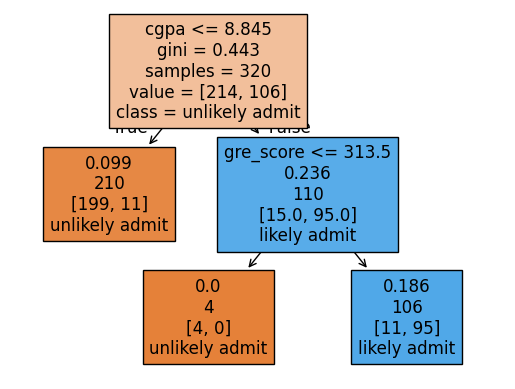

In [165]:
tree.plot_tree(dt, feature_names = x_train.columns, max_depth = 3, class_names = ['unlikely admit', 'likely admit'], label = 'root', filled = True)
print(tree.export_text(dt, feature_names = X.columns.tolist()))

We will check whether cgpa is the best split, using the gini function and information gain function.

In [166]:
def gini(data):
    """Calculate the Gini Impurity Score
    """
    data = pd.Series(data)
    return 1 - sum(data.value_counts(normalize=True)**2)

gi = gini(y_train)
print(f'Gini impurity at root: {round(gi,3)}')



Gini impurity at root: 0.443


In [167]:
def info_gain(left, right, current_impurity):
    """Information Gain associated with creating a node/split data.
    Input: left, right are data in left branch, right banch, respectively
    current_impurity is the data impurity before splitting into left, right branches
    """
    # weight for gini score of the left branch
    w = float(len(left)) / (len(left) + len(right))
    return current_impurity - w * gini(left) - (1 - w) * gini(right)


With each value of cgpa, we have a different information gain value, so we create a list that contains each information gain value corresponding to cgpa and sort to choose the cgpa to split that has the biggest information gain.

In [168]:
info_gain_list = []
for i in x_train.cgpa.unique():
    left = y_train[x_train.cgpa<=i]
    right = y_train[x_train.cgpa>i]
    info_gain_list.append([i, info_gain(left, right, gi)])

ig_table = pd.DataFrame(info_gain_list, columns=['split_value', 'info_gain']).sort_values('info_gain',ascending=False)
split_value = ig_table['split_value'].iloc[0]
print(ig_table.head(10))
print(f'The split value we use is {round(split_value, 2)}')


     split_value  info_gain
10          8.84   0.296932
124         8.85   0.291464
139         8.88   0.290704
18          8.90   0.290054
98          8.83   0.287810
110         8.87   0.286050
152         8.94   0.284714
57          8.96   0.284210
96          8.80   0.283371
21          9.00   0.283364
The split value we use is 8.84


Plot a graph to see the change of each information value corresponding to the split value. Note that the **star point** is best cgpa split value.

Text(0, 0.5, 'info gain')

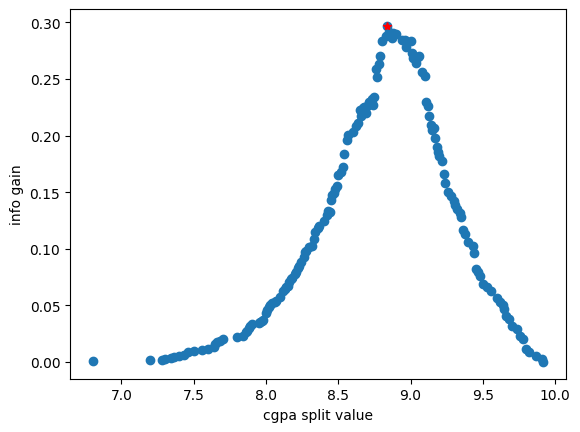

In [169]:
plt.plot(ig_table['split_value'], ig_table['info_gain'],'o')
plt.plot(ig_table['split_value'].iloc[0], ig_table['info_gain'].iloc[0],'r*')
plt.xlabel('cgpa split value')
plt.ylabel('info gain')


##Decision for Regression

In [170]:
X = df.loc[:,'gre_score':'research']
y = df['chance_of_admit']

In [171]:
x_train, x_test, y_train, y_test = train_test_split(X,y, random_state=0, test_size=0.2)
dtr = DecisionTreeRegressor(max_depth=3, ccp_alpha=0.001)
dtr.fit(x_train, y_train)
y_pred = dtr.predict(x_test)
print(dtr.score(x_test, y_test))

0.5230242793515552


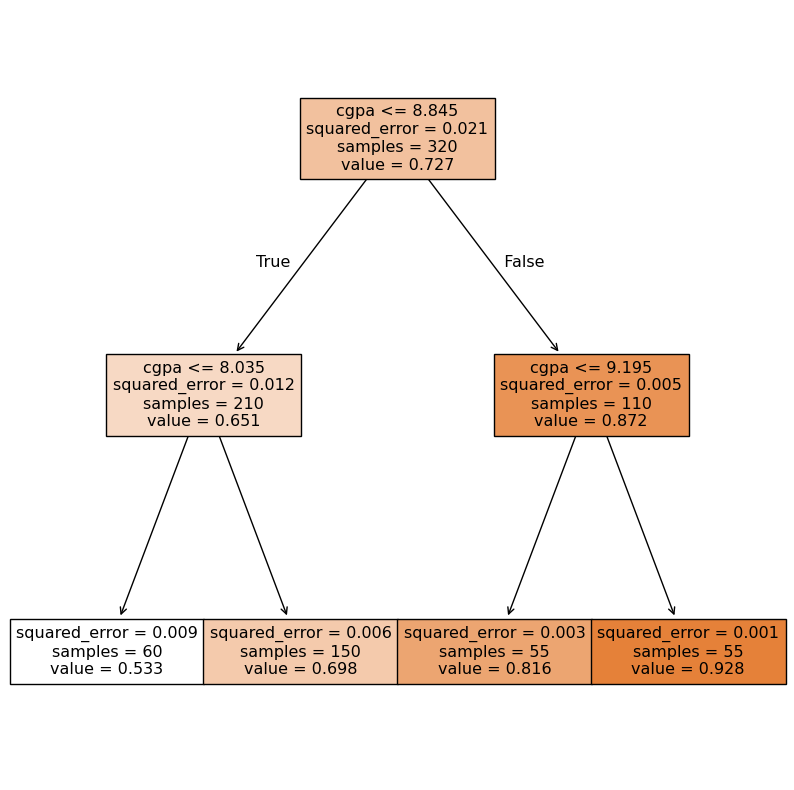

In [172]:
plt.figure(figsize=(10,10))
tree.plot_tree(dtr, feature_names = x_train.columns,
               max_depth=2, filled=True);

Decision Tree Regression is familiar with decision tree classifier, but there are some differences between them. In this algorithm uses the MSE ( Mean Squared Error) value instead of Gini impurity. The goal is to decrease the MSE value and increase the information value, which we call MSE gain in this algorithm. And we do not classify data anymore; we need the value that predict base on the feature, so the value is calculated by the mean of the target value of all samples in the node. Similar to previous we use mse, mse gain function to find split value.

In [173]:
def mse(data):
    """Calculate the MSE of a data set
    """
    return np.mean((data - data.mean())**2)

def mse_gain(left, right, current_mse):
    """Information Gain (MSE) associated with creating a node/split data based on MSE.
    Input: left, right are data in left branch, right banch, respectively
    current_impurity is the data impurity before splitting into left, right branches
    """
    # weight for gini score of the left branch
    w = float(len(left)) / (len(left) + len(right))
    return current_mse - w * mse(left) - (1 - w) * mse(right)

# check value of root node
root_mean = y_train.mean()
print(f'The mean of y_train (root node): {round(root_mean, 3)}')

# Check the value of sub node (ie.: cgpa <= 8.845)
left_node_y = y_train[x_train['cgpa'] <= 8.845]
print(f'Total sample in the left node: {len(left_node_y)}')
print(f'The mean of y in the left node: {round(left_node_y.mean(), 3)}')

m = mse(y_train)
print(f'MSE at root: {round(m,3)}')

mse_gain_list = []
for i in x_train.cgpa.unique():
    left = y_train[x_train.cgpa<=i]
    right = y_train[x_train.cgpa>i]
    mse_gain_list.append([i, mse_gain(left, right, m)])

mse_table = pd.DataFrame(mse_gain_list,columns=['split_value', 'info_gain']).sort_values('info_gain',ascending=False)
print(mse_table.head(10))


The mean of y_train (root node): 0.727
Total sample in the left node: 210
The mean of y in the left node: 0.651
MSE at root: 0.021
     split_value  info_gain
10          8.84   0.011065
96          8.80   0.011037
98          8.83   0.011023
124         8.85   0.010985
125         8.73   0.010939
110         8.87   0.010932
139         8.88   0.010895
1           8.70   0.010894
17          8.76   0.010858
140         8.74   0.010850


Text(0, 0.5, 'info gain')

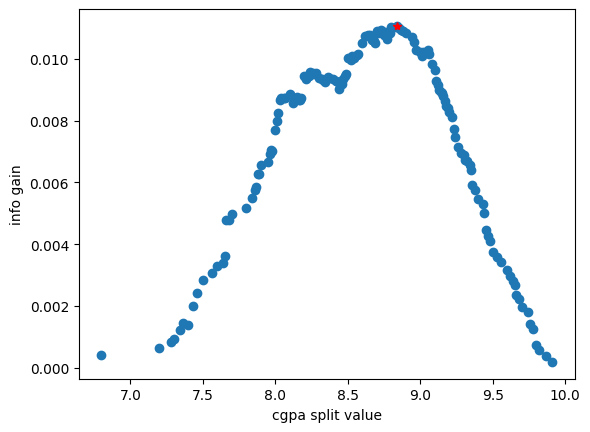

In [174]:
plt.plot(mse_table['split_value'], mse_table['info_gain'],'o')
plt.plot(mse_table['split_value'].iloc[0], mse_table['info_gain'].iloc[0],'r*')
plt.xlabel('cgpa split value')
plt.ylabel('info gain')


Depending on the depth of the tree, the predicted values can be limited. In this example, only four unique predicted values are possible, which we can verify. This is something to be aware of when using a decision tree regressor, unlike linear/logistic regression, not all output values may be possible.

In [175]:
np.unique(dtr.predict(x_train))


array([0.53283333, 0.6976    , 0.81618182, 0.92781818])